In [17]:
import sys
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql+psycopg2:///nhs_rtt"
)

In [18]:
df = pd.read_sql(
    "SELECT * FROM rtt_waiting_list",
    engine
)

df.head()

,reporting_month,region_code,provider_code,provider_name,treatment_function_code,treatment_function,total_incomplete_pathways,total_within_18_weeks,pct_within_18_weeks,median_wait_weeks,p92_wait_weeks,total_52_plus,total_65_plus,total_78_plus,pct_52_plus
0,2026-03-01,Y56,R1H,BARTS HEALTH NHS TRUST,C_100,General Surgery Service,4918,2804,0.570150,15.05,41.60,67,1,0,0.013623
1,2026-03-01,Y56,R1H,BARTS HEALTH NHS TRUST,C_101,Urology Service,6514,3930,0.603316,14.61,39.87,22,0,0,0.003377
2,2026-03-01,Y56,R1H,BARTS HEALTH NHS TRUST,C_110,Trauma and Orthopaedic Service,8564,4773,0.557333,15.83,40.46,72,1,0,0.008407
3,2026-03-01,Y56,R1H,BARTS HEALTH NHS TRUST,C_120,Ear Nose and Throat Service,6592,3109,0.471632,19.34,44.71,135,1,0,0.020479
4,2026-03-01,Y56,R1H,BARTS HEALTH NHS TRUST,C_130,Ophthalmology Service,5583,3782,0.677414,11.64,32.85,3,0,0,0.000537


In [19]:
total_waiting = df["total_incomplete_pathways"].sum()

total_52 = df["total_52_plus"].sum()

pct_18 = (
    df["total_within_18_weeks"].sum()
    /
    df["total_incomplete_pathways"].sum()
)

print(total_waiting)
print(total_52)
print(pct_18)

13146468
180350
0.6470324957243269


In [20]:
providers = (
    df.groupby("provider_name")
      ["total_incomplete_pathways"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

providers

provider_name
MID AND SOUTH ESSEX NHS FOUNDATION TRUST                         347954
MANCHESTER UNIVERSITY NHS FOUNDATION TRUST                       331136
ROYAL FREE LONDON NHS FOUNDATION TRUST                           266618
NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST                      258042
BARTS HEALTH NHS TRUST                                           242860
UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST                      227914
UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST                 225042
GUY'S AND ST THOMAS' NHS FOUNDATION TRUST                        211184
UNIVERSITY HOSPITALS OF DERBY AND BURTON NHS FOUNDATION TRUST    186544
UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST             178644
Name: total_incomplete_pathways, dtype: int64

/tmp/ipykernel_9915/2824325326.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


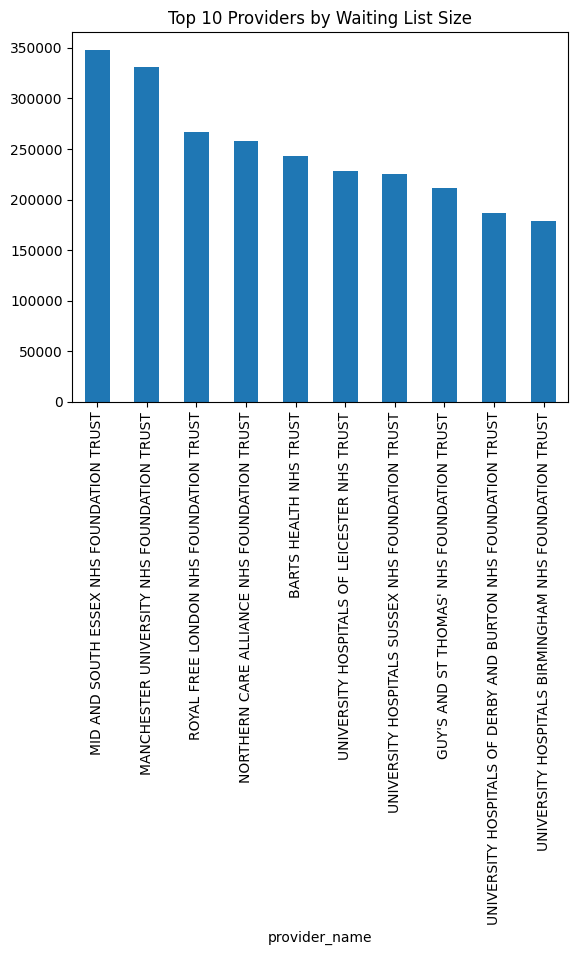

In [23]:
import matplotlib.pyplot as plt

providers.plot(kind="bar")

plt.title(
    "Top 10 Providers by Waiting List Size"
)

plt.tight_layout()

plt.show()